# Automated Barcoding Detection

Note to self: scriptify the manual line segment extraction, which may be useful

E2E file
→ select B-scan
→ obtain BM boundary
→ flatten to BM
→ crop fixed depth below BM
→ normalize ROI
→ return arrays + metadata

## E2E Prep, Flattening, and Cropping

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.barcode.data import (
    inspect_volume_layers,
    load_e2e_volume,
    preprocess_bscan,
)

In [2]:
E2E_PATH = PROJECT_ROOT / "data" / "heyex" / "meta" / "ea8.E2E"

volume = load_e2e_volume(E2E_PATH)

print("Volume type:", type(volume))
print("Volume shape:", volume.shape)
print("Available layers:", inspect_volume_layers(volume))

Volume type: <class 'eyepy.core.eyevolume.EyeVolume'>
Volume shape: (97, 496, 512)
Available layers: ['ILM', 'BM', 'RNFL', 'GCL', 'IPL', 'INL', 'OPL', 'ELM', 'PR1', 'PR2', 'RPE']


In [3]:
# Select initial BScan
BSCAN_INDEX = 41

bscan = volume[BSCAN_INDEX]

print("B-scan index:", BSCAN_INDEX)
print("B-scan shape:", bscan.shape)
print("Metadata:", bscan.meta)

B-scan index: 41
B-scan shape: (496, 512)
Metadata: start_pos: (-9.799324989318848, 0.9622939825057983)
end_pos: (10.2138090133667, 1.605315089225769)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -9.799324989318848
start_y: 0.9622939825057983
end_x: 10.2138090133667
end_y: 1.605315089225769
zero1: 0
unknown1: 66557856.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContainer: 
    5987.3955078125
    116.47171783447266
zero3: 0
imgSizeWidth: 512
n_bscans: 97
aktImage: 41
scan_pattern: 1
center_x: 0.20724201202392578
center_y: 1.2838045358657837
unknown4: 1
acquisitionTime: 2024-02-16T23:22:36.250999
numAve: 0
quality: 0.8416000008583069
unknown5: 0.9146999716758728


In [4]:
processed = preprocess_bscan(
    volume=volume,
    bscan_index=41,
    bm_layer_name="BM",
    depth_below_bm=150,
)

print("Raw shape:", processed.raw_bscan.shape)
print("BM boundary shape:", processed.bm_boundary.shape)
print("Flattened shape:", processed.flattened_bscan.shape)
print("Sub-BM crop shape:", processed.sub_bm_crop.shape)
print("Reference row:", processed.reference_row)

Raw shape: (496, 512)
BM boundary shape: (512,)
Flattened shape: (496, 512)
Sub-BM crop shape: (150, 512)
Reference row: 253


In [5]:
print("BM minimum row:", processed.bm_boundary.min())
print("BM maximum row:", processed.bm_boundary.max())
print("BM median row:", np.median(processed.bm_boundary))
print("First 10 coordinates:", processed.bm_boundary[:10])

BM minimum row: 215.13289
BM maximum row: 273.66016
BM median row: 252.8485
First 10 coordinates: [220.51967 220.88426 221.2488  221.61324 221.97752 222.34163 222.70554
 223.06929 223.43295 223.79666]


In [6]:
bm_layer = volume.layers["BM"]

print("Type:", type(bm_layer))
print("Attributes:", [name for name in dir(bm_layer) if not name.startswith("_")])

if hasattr(bm_layer, "data"):
    print("Data type:", type(bm_layer.data))
    print("Data shape:", np.asarray(bm_layer.data).shape)

Type: <class 'eyepy.core.annotations.EyeVolumeLayerAnnotation'>
Attributes: ['data', 'knots', 'layer_indices', 'meta', 'name', 'volume']
Data type: <class 'numpy.ndarray'>
Data shape: (97, 512)


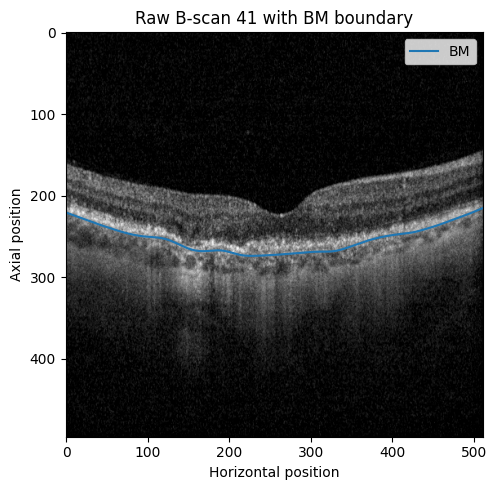

In [7]:
# Raw Scan with BM overley
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.raw_bscan,
    cmap="gray",
)

plt.plot(
    np.arange(processed.bm_boundary.size),
    processed.bm_boundary,
    linewidth=1.5,
    label="BM",
)

plt.title(f"Raw B-scan {processed.bscan_index} with BM boundary")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

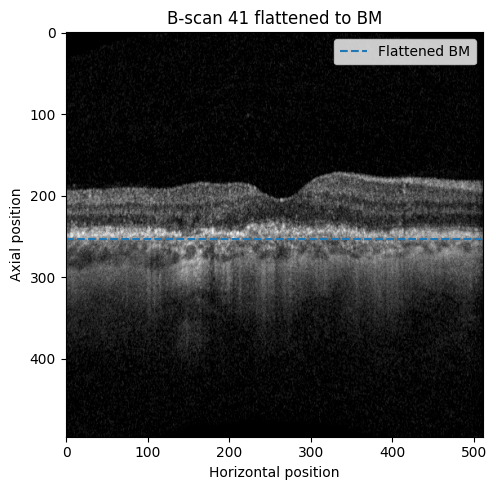

In [8]:
# Flattened scan
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.flattened_bscan,
    cmap="gray",
)

plt.axhline(
    processed.reference_row,
    linestyle="--",
    linewidth=1.5,
    label="Flattened BM",
)

plt.title(f"B-scan {processed.bscan_index} flattened to BM")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

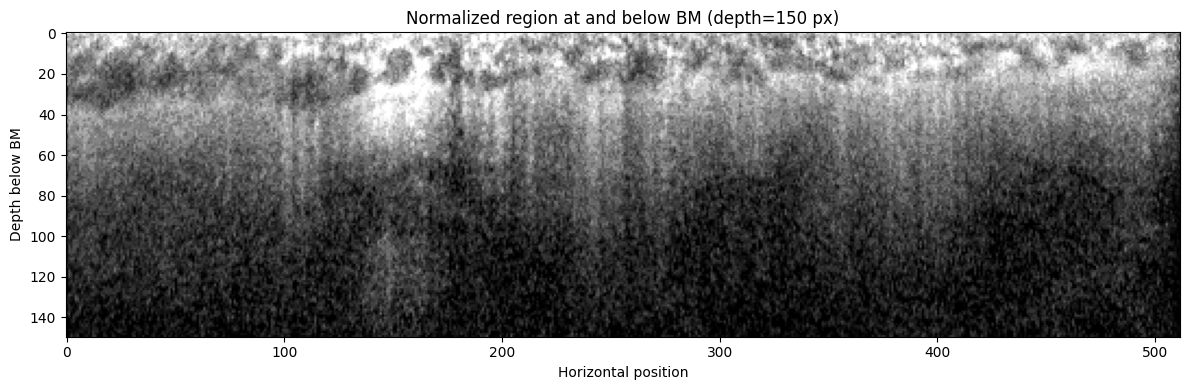

In [9]:
# Region below BM
plt.figure(figsize=(12, 4))

plt.imshow(
    processed.normalized_crop,
    cmap="gray",
    aspect="auto",
)

plt.title(
    f"Normalized region at and below BM "
    f"(depth={processed.depth_below_bm} px)"
)
plt.xlabel("Horizontal position")
plt.ylabel("Depth below BM")
plt.tight_layout()
plt.show()

I actually suspect vertical persistence is going to end up being the key feature rather than brightness. The human eye is picking up those long, coherent bright columns—not just bright spots—and our algorithm should try to quantify exactly that. That also aligns well with the paper you’re using as inspiration: reduce the OCT to a robust 1D signal along the horizontal axis, segment contiguous abnormal regions, and then perform all measurements within those detected intervals.

## Model and Training


In [10]:
# Exclude the bright BM/RPE band near the top of the crop.
ANALYSIS_START = 15
ANALYSIS_END = 130

roi = processed.normalized_crop[
    ANALYSIS_START:ANALYSIS_END,
    :
]

print("Full sub-BM crop shape:", processed.normalized_crop.shape)
print("Analysis ROI shape:", roi.shape)

Full sub-BM crop shape: (150, 512)
Analysis ROI shape: (115, 512)


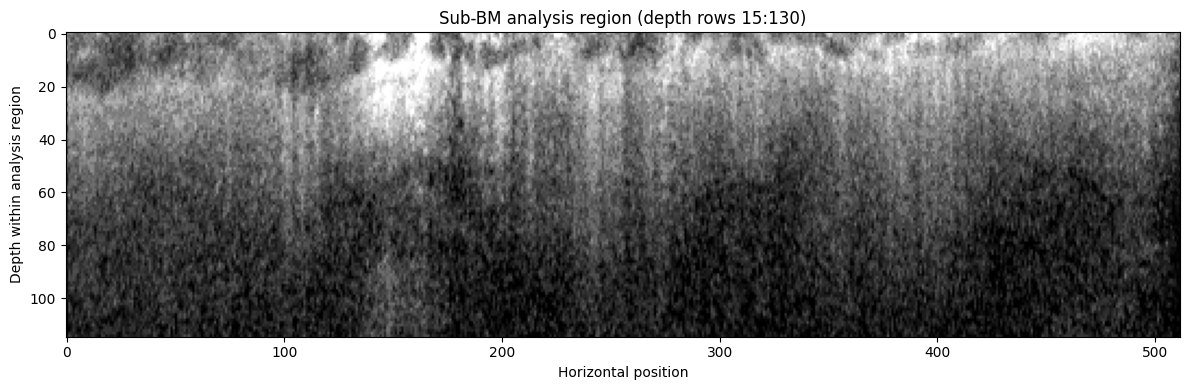

In [11]:
plt.figure(figsize=(12, 4))

plt.imshow(
    roi,
    cmap="gray",
    aspect="auto",
)

plt.title(
    f"Sub-BM analysis region "
    f"(depth rows {ANALYSIS_START}:{ANALYSIS_END})"
)
plt.xlabel("Horizontal position")
plt.ylabel("Depth within analysis region")
plt.tight_layout()
plt.show()

In [12]:
# Once we know which features work, we'll move them to the model file
import numpy as np
from scipy.ndimage import gaussian_filter1d


def longest_true_run(values: np.ndarray) -> int:
    """
    Return the length of the longest consecutive True run.
    """
    values = np.asarray(values, dtype=bool)

    longest = 0
    current = 0

    for value in values:
        if value:
            current += 1
            longest = max(longest, current)
        else:
            current = 0

    return longest


def compute_column_features(
    roi: np.ndarray,
    bright_threshold: float | None = None,
) -> dict[str, np.ndarray]:
    """
    Compute candidate barcoding features for every image column.

    Parameters
    ----------
    roi:
        Normalized sub-BM region with shape (depth, width).
    bright_threshold:
        Global intensity threshold defining a bright pixel. If omitted,
        the 75th percentile of the full ROI is used.
    """
    roi = np.asarray(roi, dtype=np.float32)

    if roi.ndim != 2:
        raise ValueError(
            f"Expected a 2D ROI, received shape {roi.shape}."
        )

    if bright_threshold is None:
        bright_threshold = float(
            np.quantile(roi, 0.75)
        )

    bright_mask = roi >= bright_threshold

    column_mean = roi.mean(axis=0)
    column_q75 = np.quantile(roi, 0.75, axis=0)
    column_q90 = np.quantile(roi, 0.90, axis=0)
    column_std = roi.std(axis=0)

    # Fraction of the analyzed depth that remains bright.
    bright_fraction = bright_mask.mean(axis=0)

    # Longest uninterrupted vertical run of bright pixels.
    longest_run = np.array(
        [
            longest_true_run(bright_mask[:, x])
            for x in range(roi.shape[1])
        ],
        dtype=np.float32,
    )

    longest_run_fraction = longest_run / roi.shape[0]

    return {
        "mean": column_mean,
        "q75": column_q75,
        "q90": column_q90,
        "std": column_std,
        "bright_fraction": bright_fraction,
        "longest_run_fraction": longest_run_fraction,
        "bright_threshold": np.array(bright_threshold),
    }

In [13]:
features = compute_column_features(roi)

print(
    "Global bright-pixel threshold:",
    float(features["bright_threshold"]),
)

for name, values in features.items():
    if name == "bright_threshold":
        continue

    print(
        f"{name:22s}",
        f"shape={values.shape}",
        f"min={values.min():.4f}",
        f"max={values.max():.4f}",
    )

Global bright-pixel threshold: 0.503311276435852
mean                   shape=(512,) min=0.1235 max=0.5340
q75                    shape=(512,) min=0.1887 max=0.8510
q90                    shape=(512,) min=0.3576 max=1.0000
std                    shape=(512,) min=0.1403 max=0.3213
bright_fraction        shape=(512,) min=0.0261 max=0.4522
longest_run_fraction   shape=(512,) min=0.0174 max=0.3913


In [14]:
# Smooth profiles to reduce noise
SMOOTH_SIGMA = 4

smoothed_features = {
    name: gaussian_filter1d(
        values,
        sigma=SMOOTH_SIGMA,
    )
    for name, values in features.items()
    if name != "bright_threshold"
}

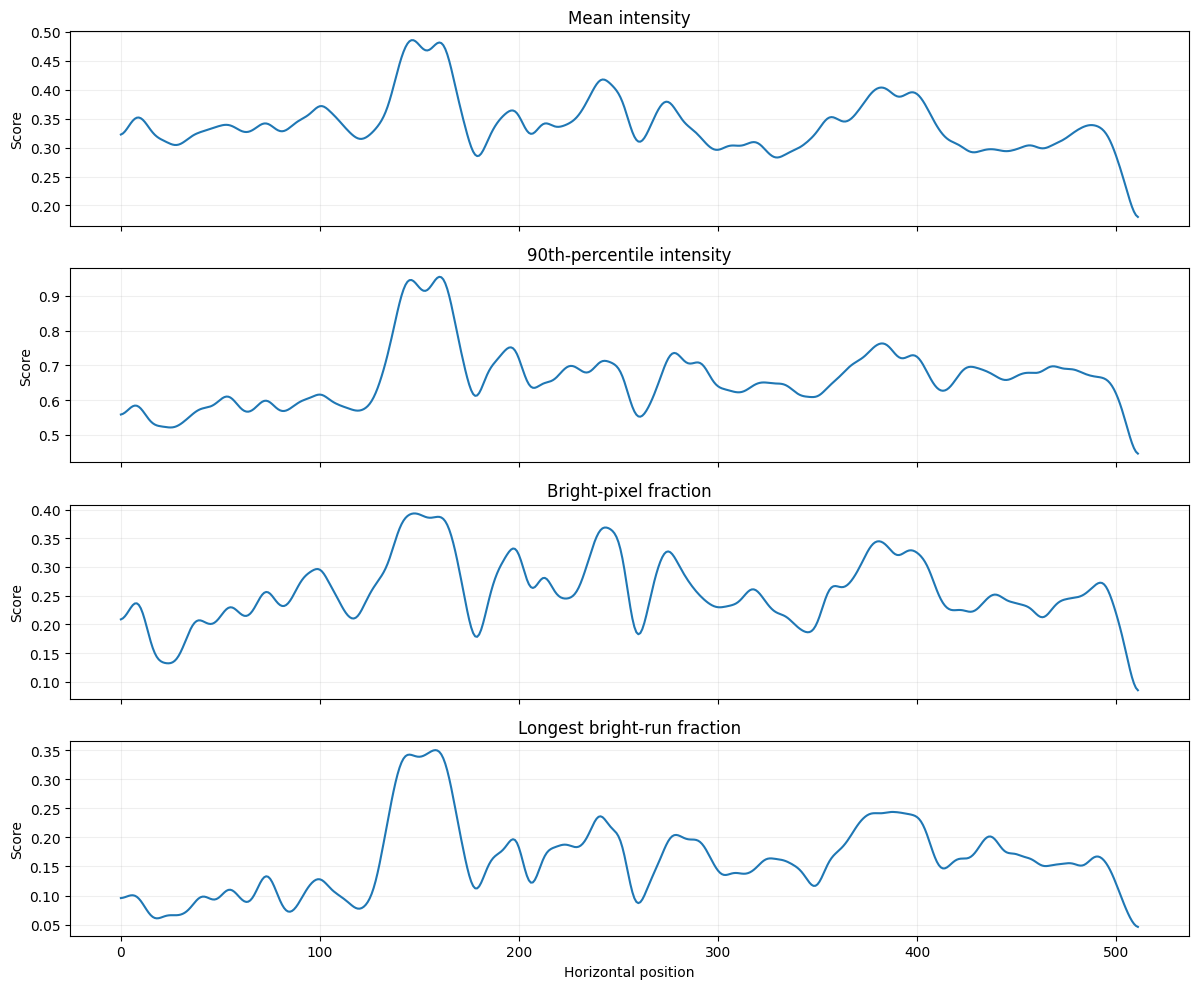

In [15]:
feature_names = [
    "mean",
    "q90",
    "bright_fraction",
    "longest_run_fraction",
]

feature_titles = {
    "mean": "Mean intensity",
    "q90": "90th-percentile intensity",
    "bright_fraction": "Bright-pixel fraction",
    "longest_run_fraction": "Longest bright-run fraction",
}

fig, axes = plt.subplots(
    len(feature_names),
    1,
    figsize=(12, 10),
    sharex=True,
)

for ax, name in zip(axes, feature_names):
    ax.plot(
        smoothed_features[name],
        linewidth=1.5,
    )

    ax.set_title(feature_titles[name])
    ax.set_ylabel("Score")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Horizontal position")

plt.tight_layout()
plt.show()

The two most important profiles are `bright_fraction` and `longest_run_fraction`. The first measures how much of the sub-BM column is bright. The second measures whether that brightness forms a persistent vertical streak.

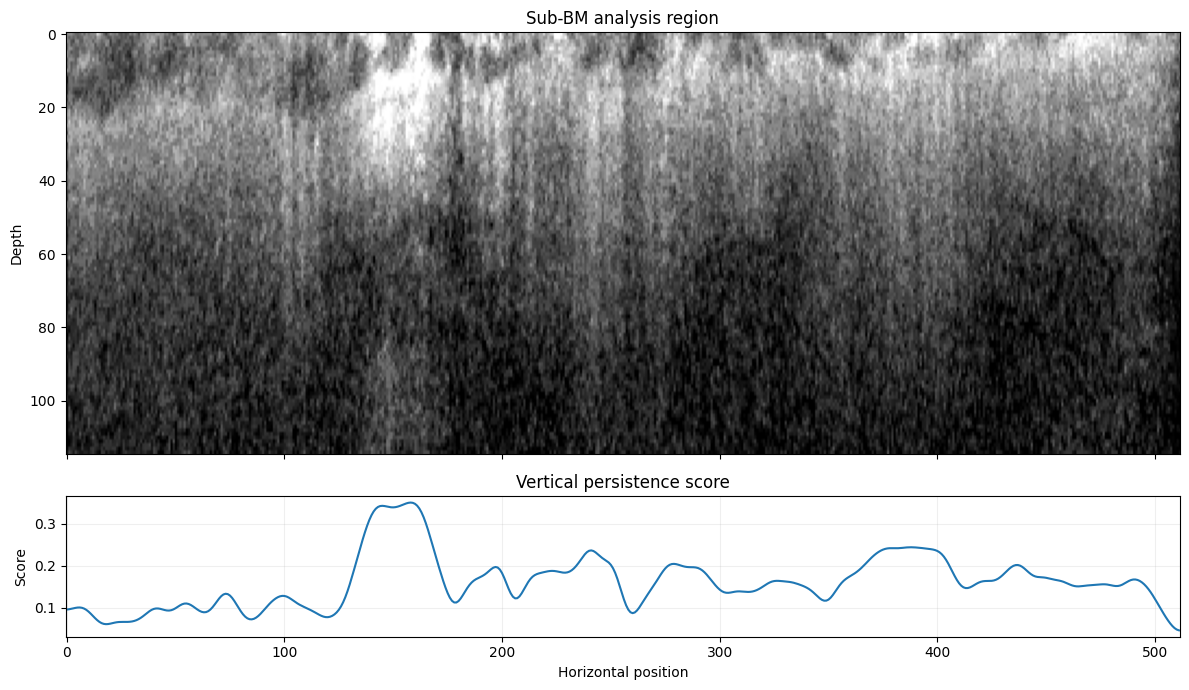

In [16]:
candidate_signal = smoothed_features[
    "longest_run_fraction"
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
    },
)

axes[0].imshow(
    roi,
    cmap="gray",
    aspect="auto",
)
axes[0].set_title("Sub-BM analysis region")
axes[0].set_ylabel("Depth")

axes[1].plot(
    candidate_signal,
    linewidth=1.5,
)
axes[1].set_title("Vertical persistence score")
axes[1].set_xlabel("Horizontal position")
axes[1].set_ylabel("Score")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

For the first test, define abnormal columns using the upper tail of the signal distribution rather than manually choosing a fixed score:

In [17]:
# First unsupervised threshold
SIGNAL_QUANTILE = 0.80

signal_threshold = float(
    np.quantile(
        candidate_signal,
        SIGNAL_QUANTILE,
    )
)

barcode_mask_raw = (
    candidate_signal >= signal_threshold
)

print(
    f"Signal threshold "
    f"({SIGNAL_QUANTILE:.0%} quantile): "
    f"{signal_threshold:.4f}"
)

print(
    "Initially positive columns:",
    int(barcode_mask_raw.sum()),
)

Signal threshold (80% quantile): 0.1995
Initially positive columns: 103


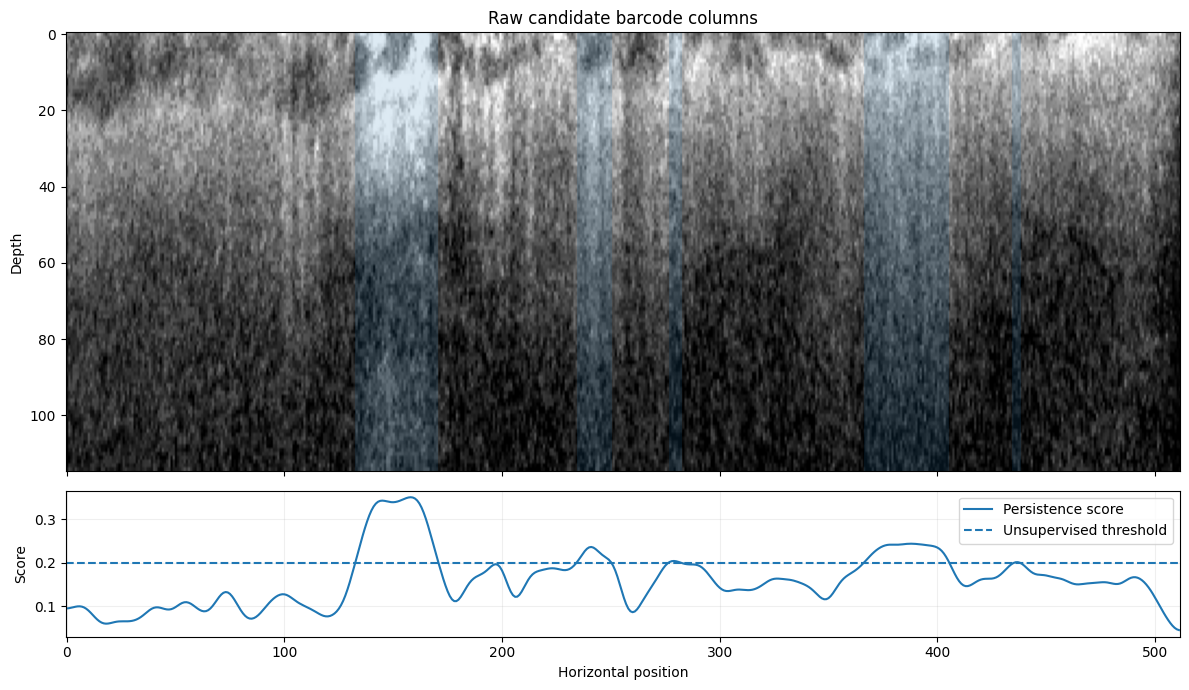

In [18]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
    },
)

axes[0].imshow(
    roi,
    cmap="gray",
    aspect="auto",
)

positive_x = np.flatnonzero(barcode_mask_raw)

for x in positive_x:
    axes[0].axvspan(
        x - 0.5,
        x + 0.5,
        alpha=0.15,
    )

axes[0].set_title("Raw candidate barcode columns")
axes[0].set_ylabel("Depth")

axes[1].plot(
    candidate_signal,
    label="Persistence score",
)

axes[1].axhline(
    signal_threshold,
    linestyle="--",
    label="Unsupervised threshold",
)

axes[1].set_xlabel("Horizontal position")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Evaluation


## Measurement Extraction